In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果系统中安装了 "SimHei" 字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题


In [2]:
df = pd.read_csv('../2.1-data_analysis/score.csv')

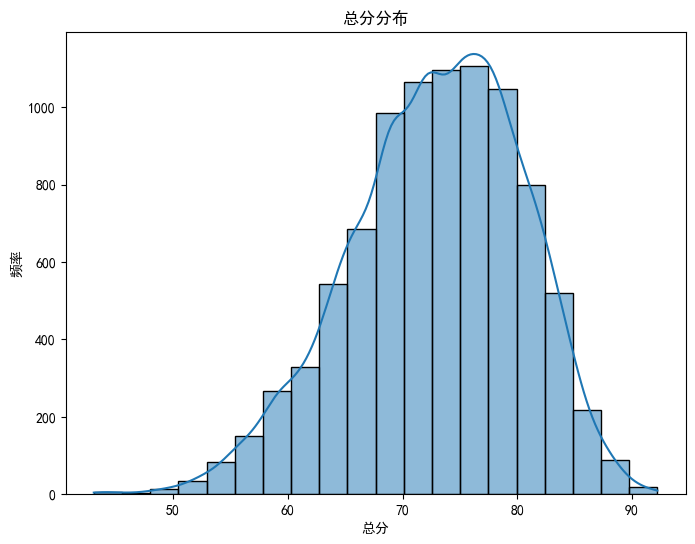

In [3]:
plt.figure(figsize=(8, 6))
sns.histplot(df['总分'], bins=20, kde=True)
plt.title('总分分布')
plt.xlabel('总分')
plt.ylabel('频率')
plt.show()

In [4]:
# 找出得分最高和最低的文件
max_score = df.loc[df['总分'].idxmax()]
min_score = df.loc[df['总分'].idxmin()]

print('得分最高的文件：')
print(max_score)

print('得分最低的文件：')
print(min_score)

# 分析特定范围内的文件，比如得分大于70的文件
s = 70
high_score_files = df[df['总分'] > s]
print(f'得分大于{s}的文件数量：', len(high_score_files))
print(high_score_files)

得分最高的文件：
filename    connect_Callback.m
总分                      92.194
文件长度得分                     100
代码重复率得分                  90.32
关键词得分                       90
有效代码得分                   100.0
多样性得分                    80.65
Name: 2363, dtype: object
得分最低的文件：
filename    demopanel6.m
总分                 43.11
文件长度得分                60
代码重复率得分            33.33
关键词得分                  0
有效代码得分             100.0
多样性得分              22.22
Name: 7477, dtype: object
得分大于70的文件数量： 5977
                           filename      总分  文件长度得分  代码重复率得分  关键词得分  有效代码得分  \
2                       coadjoint.m  72.000      30   100.00     30   100.0   
3     coarray_selection_matrix_1d.m  82.866     100    67.57     90   100.0   
4                    coarsealign3.m  80.154      60   100.00     60   100.0   
7                     coarsegrain.m  82.456     100    64.91    100   100.0   
9                         coarsen.m  75.324      80    78.15     60   100.0   
...                             ...     ...   

各分数段数量：
分数段
0-50        18
51-60      487
61-70     2537
70-80     4392
80-90     1600
90-100      17
Name: count, dtype: int64

各分数段比例：
分数段
0-50       0.198873
51-60      5.380621
61-70     28.030052
70-80     48.525025
80-90     17.677605
90-100     0.187825
Name: proportion, dtype: float64


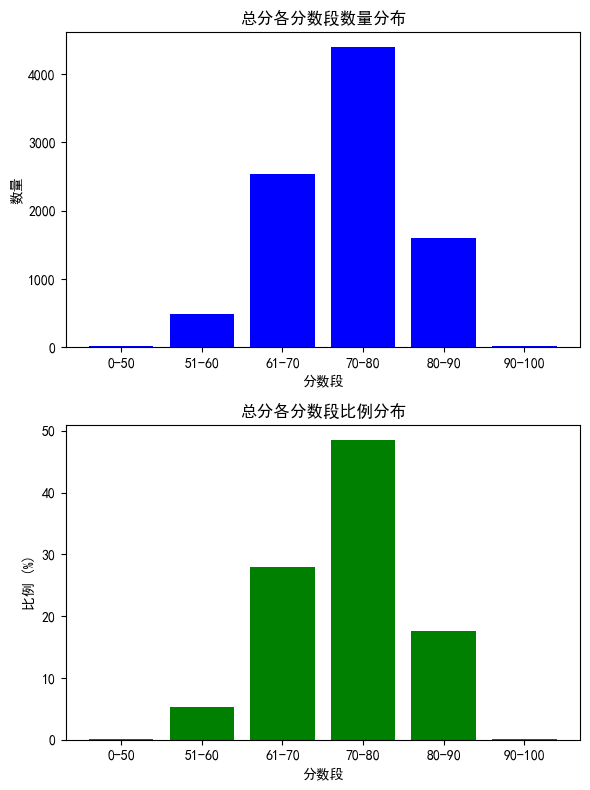

In [5]:
# 统计各个分数段的比例和数量
bins = [0, 50, 60, 70, 80, 90, 100]
labels = ['0-50', '51-60', '61-70', '70-80', '80-90', '90-100']
df['分数段'] = pd.cut(df['总分'], bins=bins, labels=labels, right=False)

count_series = df['分数段'].value_counts(sort=False)
percentage_series = df['分数段'].value_counts(normalize=True, sort=False) * 100

# 输出统计信息
print("各分数段数量：")
print(count_series)
print("\n各分数段比例：")
print(percentage_series)

# 绘制柱状图
fig, ax = plt.subplots(2, 1, figsize=(6, 8))

# 数量分布图
ax[0].bar(count_series.index.astype(str), count_series.values, color='blue')
ax[0].set_title('总分各分数段数量分布')
ax[0].set_xlabel('分数段')
ax[0].set_ylabel('数量')

# 比例分布图
ax[1].bar(percentage_series.index.astype(str), percentage_series.values, color='green')
ax[1].set_title('总分各分数段比例分布')
ax[1].set_xlabel('分数段')
ax[1].set_ylabel('比例 (%)')

# 显示图表
plt.tight_layout()
plt.show()

In [6]:
# 按分数段筛选数据
# 80-90 分：全量保留
df_80_90 = df[(df['总分'] >= 80) & (df['总分'] < 90)]

# 70-80 分：全量保留
df_70_80 = df[(df['总分'] >= 70) & (df['总分'] < 80)]

# 61-70 分：保留 30%
rate_61_70 = 0.3
df_61_70 = df[(df['总分'] >= 61) & (df['总分'] < 70)]
df_61_70_sample = df_61_70.sample(frac=rate_61_70, random_state=42)

# 51-60 分：保留 25%
rate_51_60 = 0.25
df_51_60 = df[(df['总分'] >= 51) & (df['总分'] <= 60)]
df_51_60_sample = df_51_60.sample(frac=rate_51_60, random_state=42)

# 0-50 分：保留 1%
rate_0_50 = 0.01
df_0_50 = df[(df['总分'] < 51)]
df_0_50_sample = df_0_50.sample(frac=rate_0_50, random_state=42)

# 合并筛选后的数据（使用 drop_duplicates 避免重复）
final_df = pd.concat([df_80_90, df_70_80, df_61_70_sample, df_51_60_sample, df_0_50_sample])
final_df = final_df.drop_duplicates(subset=['filename']).reset_index(drop=True)
final_df.index.name = "file_index"

# 保存结果到新的 CSV 文件
final_df.to_csv("./filtered_file.csv", index=True)

print(f"总文件数: {len(df)}")
print(f"筛选后文件数: {len(final_df)}")
print(f"  - 80-90分: {len(df_80_90)}")
print(f"  - 70-80分: {len(df_70_80)}")
print(f"  - 61-70分: {len(df_61_70_sample)}")
print(f"  - 51-60分: {len(df_51_60_sample)}")
print(f"  - 0-50分: {len(df_0_50_sample)}")


总文件数: 9051
筛选后文件数: 6842
  - 80-90分: 1600
  - 70-80分: 4392
  - 61-70分: 726
  - 51-60分: 124
  - 0-50分: 0


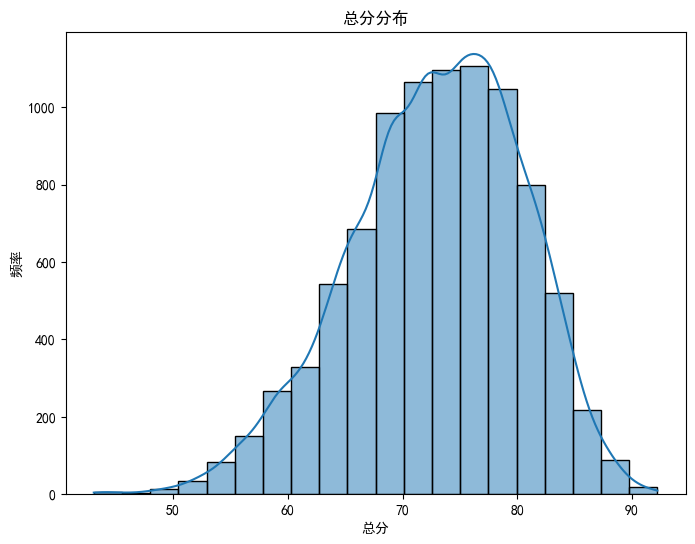

In [7]:
plt.figure(figsize=(8, 6))
sns.histplot(df['总分'], bins=20, kde=True)
plt.title('总分分布')
plt.xlabel('总分')
plt.ylabel('频率')
plt.show()

In [8]:
# 找出得分最高和最低的文件
max_score = df.loc[df['总分'].idxmax()]
min_score = df.loc[df['总分'].idxmin()]

print('得分最高的文件：')
print(max_score)

print('得分最低的文件：')
print(min_score)

# 分析特定范围内的文件，比如得分大于70的文件
s = 70
high_score_files = df[df['总分'] > s]
print(f'得分大于{s}的文件数量：', len(high_score_files))
print(high_score_files)

得分最高的文件：
filename    connect_Callback.m
总分                      92.194
文件长度得分                     100
代码重复率得分                  90.32
关键词得分                       90
有效代码得分                   100.0
多样性得分                    80.65
分数段                     90-100
Name: 2363, dtype: object
得分最低的文件：
filename    demopanel6.m
总分                 43.11
文件长度得分                60
代码重复率得分            33.33
关键词得分                  0
有效代码得分             100.0
多样性得分              22.22
分数段                 0-50
Name: 7477, dtype: object
得分大于70的文件数量： 5977
                           filename      总分  文件长度得分  代码重复率得分  关键词得分  有效代码得分  \
2                       coadjoint.m  72.000      30   100.00     30   100.0   
3     coarray_selection_matrix_1d.m  82.866     100    67.57     90   100.0   
4                    coarsealign3.m  80.154      60   100.00     60   100.0   
7                     coarsegrain.m  82.456     100    64.91    100   100.0   
9                         coarsen.m  75.324      80    78.15     60  

各分数段数量：
分数段
0-50        18
51-60      487
61-70     2537
70-80     4392
80-90     1600
90-100      17
Name: count, dtype: int64

各分数段比例：
分数段
0-50       0.198873
51-60      5.380621
61-70     28.030052
70-80     48.525025
80-90     17.677605
90-100     0.187825
Name: proportion, dtype: float64


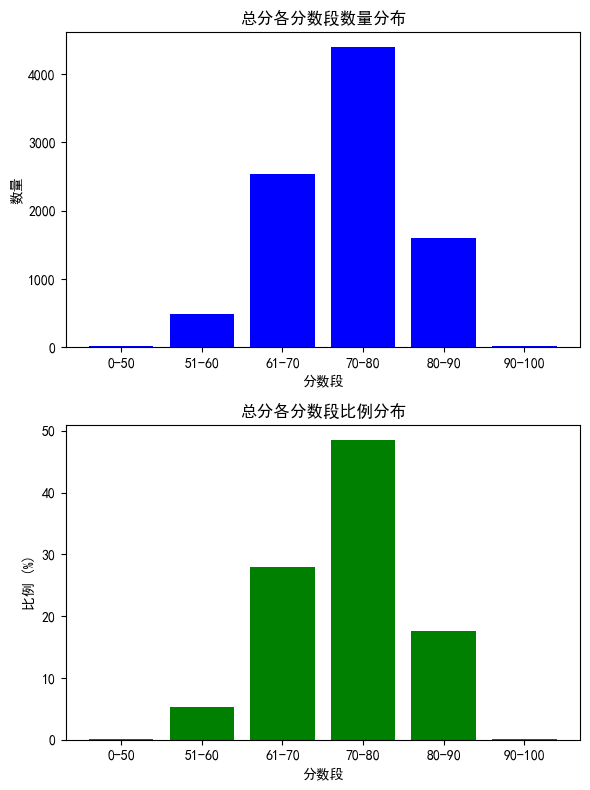

In [9]:
# 统计各个分数段的比例和数量
bins = [0, 50, 60, 70, 80, 90, 100]
labels = ['0-50', '51-60', '61-70', '70-80', '80-90', '90-100']
df['分数段'] = pd.cut(df['总分'], bins=bins, labels=labels, right=False)

count_series = df['分数段'].value_counts(sort=False)
percentage_series = df['分数段'].value_counts(normalize=True, sort=False) * 100

# 输出统计信息
print("各分数段数量：")
print(count_series)
print("\n各分数段比例：")
print(percentage_series)

# 绘制柱状图
fig, ax = plt.subplots(2, 1, figsize=(6, 8))

# 数量分布图
ax[0].bar(count_series.index.astype(str), count_series.values, color='blue')
ax[0].set_title('总分各分数段数量分布')
ax[0].set_xlabel('分数段')
ax[0].set_ylabel('数量')

# 比例分布图
ax[1].bar(percentage_series.index.astype(str), percentage_series.values, color='green')
ax[1].set_title('总分各分数段比例分布')
ax[1].set_xlabel('分数段')
ax[1].set_ylabel('比例 (%)')

# 显示图表
plt.tight_layout()
plt.show()

In [10]:
# 按分数段筛选数据
# 80-90 分：全量保留
df_80_90 = df[(df['总分'] >= 80) & (df['总分'] < 90)]

# 70-80 分：全量保留
df_70_80 = df[(df['总分'] >= 70) & (df['总分'] < 80)]

# 61-70 分：保留 30%
rate_61_70 = 0.3
df_61_70 = df[(df['总分'] >= 61) & (df['总分'] < 70)]
df_61_70_sample = df_61_70.sample(frac=rate_61_70, random_state=42)

# 51-60 分：保留 25%
rate_51_60 = 0.25
df_51_60 = df[(df['总分'] >= 51) & (df['总分'] <= 60)]
df_51_60_sample = df_51_60.sample(frac=rate_51_60, random_state=42)

# 0-50 分：保留 1%
rate_0_50 = 0.01
df_0_50 = df[(df['总分'] < 51)]
df_0_50_sample = df_0_50.sample(frac=rate_0_50, random_state=42)

# 合并筛选后的数据（使用 drop_duplicates 避免重复）
final_df = pd.concat([df_80_90, df_70_80, df_61_70_sample, df_51_60_sample, df_0_50_sample])
final_df = final_df.drop_duplicates(subset=['filename']).reset_index(drop=True)
final_df.index.name = "file_index"

# 保存结果到新的 CSV 文件
final_df.to_csv("./filtered_file.csv", index=True)

print(f"总文件数: {len(df)}")
print(f"筛选后文件数: {len(final_df)}")
print(f"  - 80-90分: {len(df_80_90)}")
print(f"  - 70-80分: {len(df_70_80)}")
print(f"  - 61-70分: {len(df_61_70_sample)}")
print(f"  - 51-60分: {len(df_51_60_sample)}")
print(f"  - 0-50分: {len(df_0_50_sample)}")


总文件数: 9051
筛选后文件数: 6842
  - 80-90分: 1600
  - 70-80分: 4392
  - 61-70分: 726
  - 51-60分: 124
  - 0-50分: 0
